step1. we will import all the libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# set default fig size for plot
plt.rcParams['figure.figsize']=(10,5)

step2. we will load the data set

In [ ]:
df=pd.read_csv("Olympics 2024.csv")
#display dataset shape
print("Dataset Shape:")
print(df.shape)

df.head(10)

Dataset Shape:
(454, 7)


,Competitions,Rank,NOC,Gold,Silver,Bronze,Total
0,Archery,1,South Korea,5,1,1,7
1,Archery,2,France*,0,1,1,2
2,Archery,3,United States,0,1,1,2
3,Archery,4,China,0,1,0,1
4,Archery,5,Germany,0,1,0,1
5,Archery,6,Mexico,0,0,1,1
6,Archery,7,Turkey,0,0,1,1
7,Artistic swimming,1,China,2,0,0,2
8,Artistic swimming,2,Great Britain,0,1,0,1
9,Artistic swimming,3,United States,0,1,0,1


step3. to get the Data Information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Competitions  454 non-null    str  
 1   Rank          454 non-null    str  
 2   NOC           454 non-null    str  
 3   Gold          454 non-null    int64
 4   Silver        454 non-null    int64
 5   Bronze        454 non-null    int64
 6   Total         454 non-null    int64
dtypes: int64(4), str(3)
memory usage: 25.0 KB


step4. Missing value analysis

In [ ]:
#calculate missing values for each 
missing_values=df.isnull().sum()
missing_values

Competitions    0
Rank            0
NOC             0
Gold            0
Silver          0
Bronze          0
Total           0
dtype: int64

step5.Visualize missing values

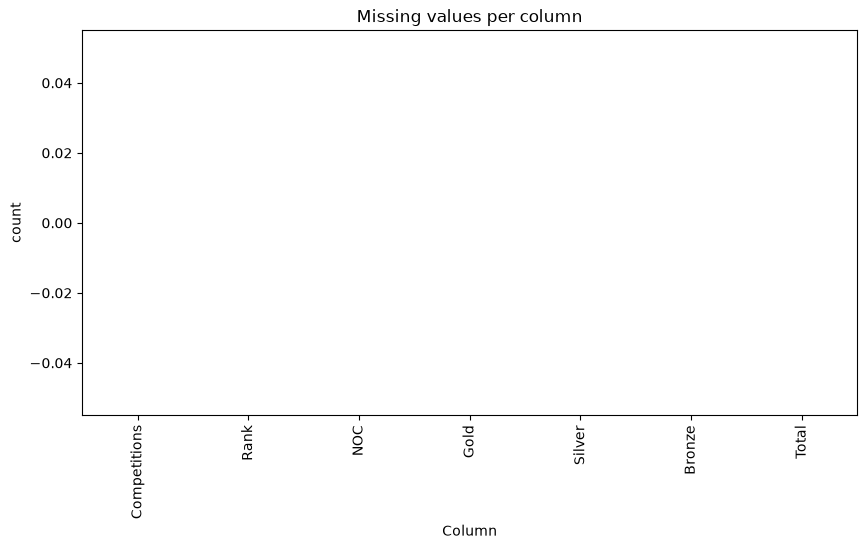

In [ ]:
# making a bar chart for missing value if present
missing_values.plot(
    kind="bar"
)

plt.title("Missing values per column")
plt.xlabel("Column")
plt.ylabel("count")

plt.show()

step6. Drop Row having more than 2 missing values

In [ ]:
#Store initial rows
initial_rows=len(df)
# keep row havingmaximum 2 missing values
df=df[df.isnull().sum(axis=1)<=2]
# calculate removed rows
rows_removed = initial_rows - len(df)
print("rows removes",rows_removed)

rows removes 0


step7. fill the total columns

In [ ]:
#Fill missing total value
# as Gold+Silver+Bronze
df["Total"]=df["Total"].fillna(
    df["Gold"]+
    df["Silver"]+
    df["Bronze"]
)
#Verify missing values
df["Total"].isnull().sum()

np.int64(0)

step8. Check Data type


In [16]:
df.dtypes

Competitions      str
Rank              str
NOC               str
Gold            int64
Silver          int64
Bronze          int64
Total           int64
dtype: object

step9. Convert Rank Column

In [ ]:
#Excat numeric value from rank column
df["Rank"]=(
    df["Rank"]
    .astype(str)
    .str.extract(r"(\d+)")
)
#conver to numeric 
df["Rank"]=pd.to_numeric(
    df["Rank"],
    errors="coerce"
)
convert to integer type
df["Rank"]=df["Rank"].astype("Int64")

df.dtypes

Competitions      str
Rank            Int64
NOC               str
Gold            int64
Silver          int64
Bronze          int64
Total           int64
dtype: object

step10. Standardize Text


In [ ]:
#conver country code to uppercase
#and remove extra space
df["NOC"]=(
    df["NOC"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["NOC"].head()

0      SOUTH KOREA
1          FRANCE*
2    UNITED STATES
3            CHINA
4          GERMANY
Name: NOC, dtype: str

step 11. find the duplicate Records

In [ ]:
#count duplicate rows
duplicates=df.duplicated().sum()

print("Duplicated records",duplicates)

Duplicated records 0


step12. Remove Ruplicate Records

In [ ]:
#remove duplicate records
df=df.drop_duplicates()

print("Duplicated after removal",df.duplicated().sum())

Duplicated after removal 0


step13.Min-Max Normalization

In [ ]:
# Normalize Gold, Silver and Bronze
# between 0 and 1
medal_columns=[
    "Gold",
    "Silver",
    "Bronze"
]
#
for col in medal_columns:

    min_val=df[col].min()
    max_val=df[col].max()

    df[col+"Normalization"]=(
        (df[col]-min_val)
        /
        (max_val-min_val)
    )

df.head()

,Competitions,Rank,NOC,Gold,Silver,Bronze,Total,GoldNormalization,SilverNormalization,BronzeNormalization
0,Archery,1,SOUTH KOREA,5,1,1,7,0.357143,0.076923,0.111111
1,Archery,2,FRANCE*,0,1,1,2,0.000000,0.076923,0.111111
2,Archery,3,UNITED STATES,0,1,1,2,0.000000,0.076923,0.111111
3,Archery,4,CHINA,0,1,0,1,0.000000,0.076923,0.000000
4,Archery,5,GERMANY,0,1,0,1,0.000000,0.076923,0.000000


step14.Feature enginering

In [ ]:
# create medal efficiency faeture
if "Event_participated " in df.columns:
    df["Medal_Efficiency"]=(
        df["Total"]
        /df["Event_participated"]
    )

df.head()

,Competitions,Rank,NOC,Gold,Silver,Bronze,Total,GoldNormalization,SilverNormalization,BronzeNormalization
0,Archery,1,SOUTH KOREA,5,1,1,7,0.357143,0.076923,0.111111
1,Archery,2,FRANCE*,0,1,1,2,0.000000,0.076923,0.111111
2,Archery,3,UNITED STATES,0,1,1,2,0.000000,0.076923,0.111111
3,Archery,4,CHINA,0,1,0,1,0.000000,0.076923,0.000000
4,Archery,5,GERMANY,0,1,0,1,0.000000,0.076923,0.000000


step15. Histogram

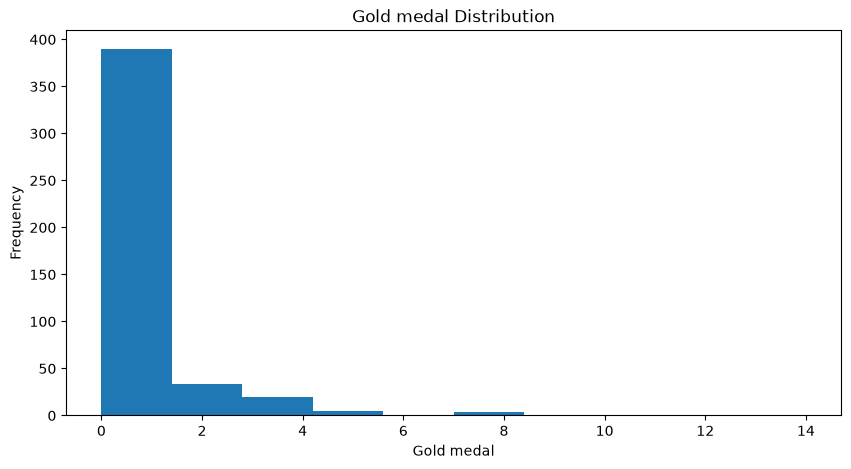

In [ ]:
#display distribution of Gold medal
plt.hist(
    df["Gold"],
    bins=10
)

plt.title("Gold medal Distribution")
plt.xlabel("Gold medal")
plt.ylabel("Frequency")

plt.show()

step 16.Top 10 Countries 


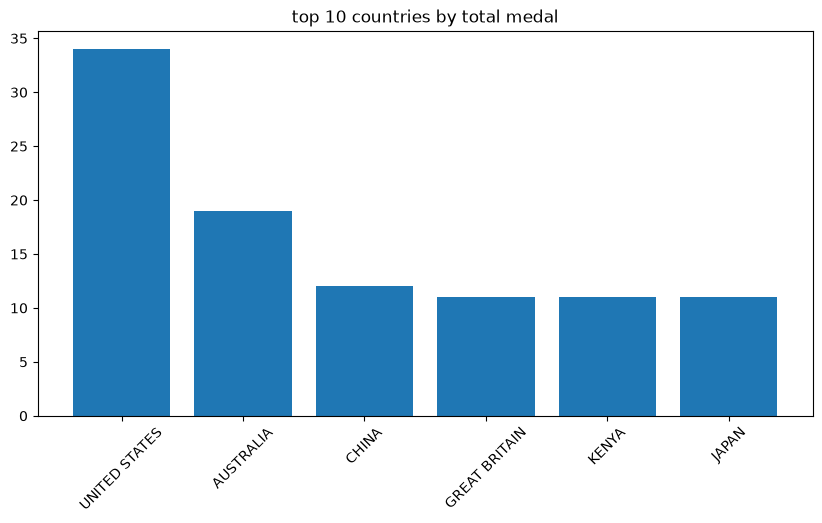

In [ ]:
#sort counrty by total medals
top10=(
    df.sort_values(
        by="Total",
        ascending=False
    )
    .head(10)
)

plt.bar(
    top10["NOC"],
    top10["Total"]
)
plt.title(
    "top 10 countries by total medal"
)

plt.xticks(rotation=45)

plt.show()

step17.Scatter plot

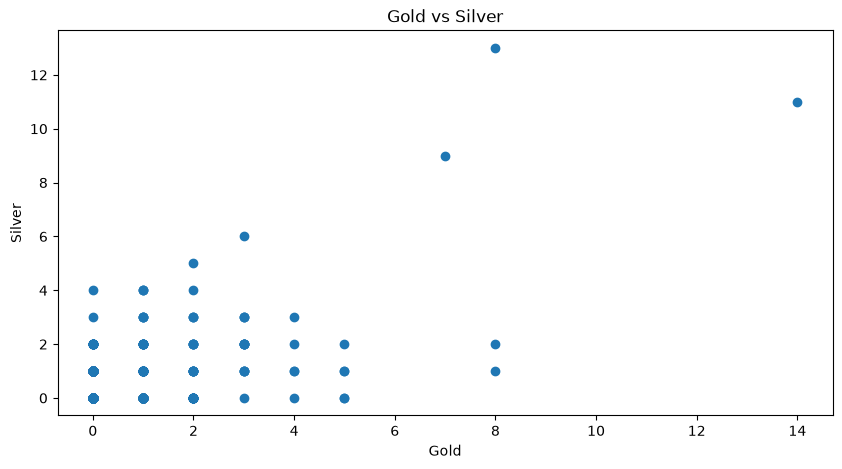

In [29]:
plt.scatter(
    df["Gold"],
    df["Silver"]
)

plt.title(
    "Gold vs Silver"
)

plt.xlabel("Gold")
plt.ylabel("Silver")

plt.show()

step18. Medal Distribution

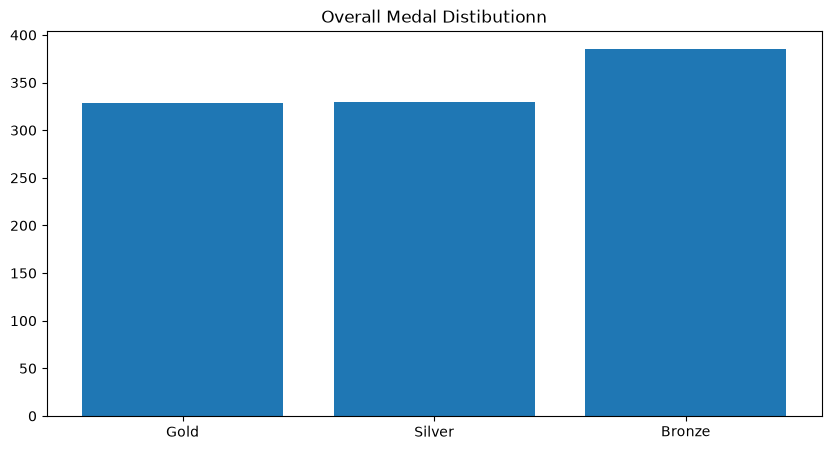

In [31]:
medal_totals={
    "Gold":
    df["Gold"].sum(),
    "Silver":
    df["Silver"].sum(),
    "Bronze":
    df["Bronze"].sum()
}

plt.bar(
    medal_totals.keys(),
    medal_totals.values()
)

plt.title(
    "Overall Medal Distibutionn"
)

plt.show()

step19.Pie Chart

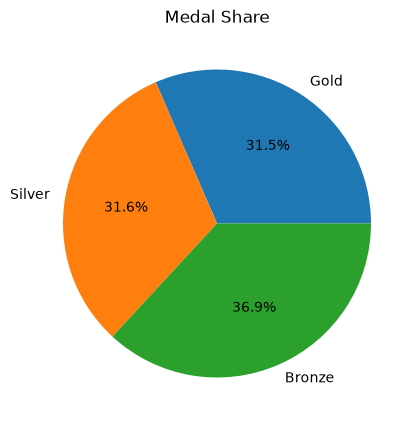

In [35]:
plt.pie(
    medal_totals.values(),
    labels=medal_totals.keys(),
    autopct="%1.1f%%"
)

plt.title(
    "Medal Share"
)

plt.show()

step20.Box plot

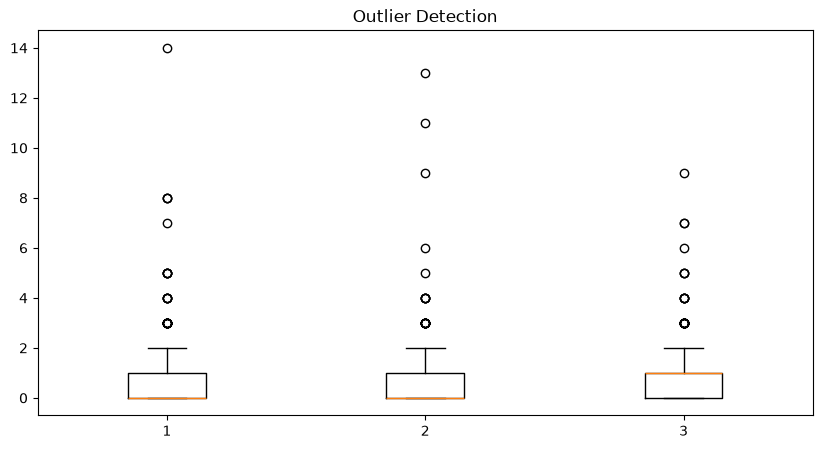

In [38]:
plt.boxplot(
    [
        df["Gold"],
        df["Silver"],
        df["Bronze"]
    ],
   label=[
        "Gold",
        "Silver",
        "Bronze"
    ]
)

plt.title(
    "Outlier Detection"
)

plt.show()

step21.Correlation Matrix

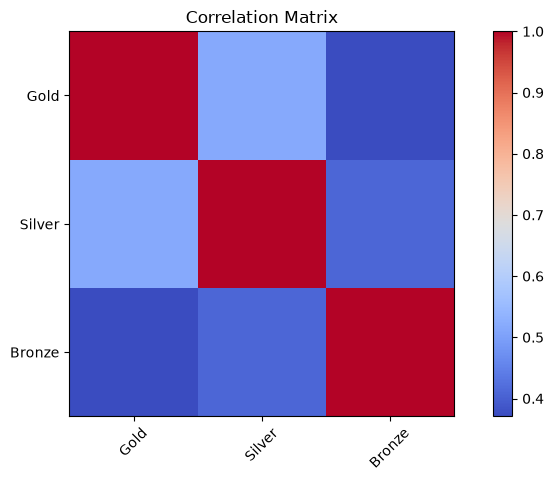

In [39]:
corr=df[
    [
        "Gold",
        "Silver",
        "Bronze"
    ]
].corr()

plt.imshow(
    corr,
    cmap="coolwarm"
)
plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)
plt.yticks( 
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Correlation Matrix"
)

plt.show()

step22. Save Clean data

In [40]:
df.to_csv(
    "olympics 2024 cleaned _csv",
    index=False
)

print(
    "File Saved Succesfully"
)

File Saved Succesfully
